# 02 — Representation Learning

**What we build here:**

A resistance-aware latent space using a VAE trained on TCGA expression,
with a contrastive loss that pulls together cell lines sharing the same
resistance programme and pushes apart those with opposite profiles.

**Architecture:**
```
Expression (97 genes)
      │
   Encoder (MLP)
      │
  z ~ N(mu, sigma)      ← VAE bottleneck
      │
   Decoder (MLP)
      │
Reconstructed expression

Loss = reconstruction + beta*KL + gamma*contrastive
```

**Why this is scientifically coherent:**
The contrastive signal comes from GDSC2 pharmacology — not arbitrary augmentations.
Two cell lines are a positive pair if they share the same resistance class
for a given pathway. This forces the latent space to organise by
resistance mechanism rather than tissue of origin.

**Inputs:**
- `data/tcga_expr_norm.parquet` — 11060 × 97
- `data/ccle_expr_norm.parquet` — 486 × 97
- `data/resistance_labels.csv` — 965 × 23

**Outputs:**
- `data/tcga_embeddings.parquet` — 11060 × latent_dim
- `data/ccle_embeddings.parquet` — 486 × latent_dim
- `models/vae.pt` — saved model weights
- `figures/02_umap_cancer_type.png`
- `figures/02_umap_resistance.png`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab Notebooks/Machine_learning_for_cancer_therapy_resistance_and_metastasis_prediction/01_data_harmonisation

/content/drive/MyDrive/Colab Notebooks/Machine_learning_for_cancer_therapy_resistance_and_metastasis_prediction/01_data_harmonisation


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from pathlib import Path

In [4]:
Path('figures').mkdir(exist_ok=True)
Path('models').mkdir(exist_ok=True)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [6]:
# Load data
tcga      = pd.read_parquet('data/tcga_expr_norm.parquet')
ccle      = pd.read_parquet('data/ccle_expr_norm.parquet')
resist    = pd.read_csv('data/resistance_labels.csv', index_col=0)
tcga_clin = pd.read_csv('data/tcga_clinical.csv', index_col=0)
genes     = pd.read_csv('data/shared_genes.csv', header=None)[0].tolist()

# Align CCLE to resistance labels
common_cl = ccle.index.intersection(resist.index)
ccle   = ccle.loc[common_cl]
resist = resist.loc[common_cl]

N_GENES   = len(genes)          # 97
N_PATHWAY = resist.shape[1]     # 23
LATENT    = 32                  # small — 97 input genes don't justify larger

print(f'TCGA: {tcga.shape} | CCLE: {ccle.shape} | Resistance: {resist.shape}')
print(f'Latent dim: {LATENT}')

TCGA: (11060, 97) | CCLE: (486, 97) | Resistance: (486, 23)
Latent dim: 32


## Model definition

In [7]:
class VAE(nn.Module):
    """
    Simple VAE for gene expression.
    97 genes -> 64 -> 32 -> latent(32) -> 32 -> 64 -> 97

    Small and interpretable — appropriate for 97 input features.
    """
    def __init__(self, n_genes=97, latent_dim=32, hidden=64, dropout=0.1):
        super().__init__()
        # Encoder
        self.enc = nn.Sequential(
            nn.Linear(n_genes, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
        )
        self.fc_mu      = nn.Linear(hidden, latent_dim)
        self.fc_log_var = nn.Linear(hidden, latent_dim)

        # Decoder
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_genes),
        )

    def encode(self, x):
        h = self.enc(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h).clamp(-10, 5)
        return mu, log_var

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterise(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var


def vae_loss(recon, x, mu, log_var, beta=1.0):
    recon_loss = F.mse_loss(recon, x, reduction='mean')
    kl = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + beta * kl, recon_loss, kl


def contrastive_loss(z_a, z_b, labels, margin=1.0):
    """
    Contrastive loss (Hadsell et al.):
    - labels=1: same resistance class (positive pair) -> pull together
    - labels=0: different class (negative pair) -> push apart

    z_a, z_b: embeddings of paired samples [B, latent_dim]
    labels:   1 = same class, 0 = different class [B]
    """
    dist = F.pairwise_distance(z_a, z_b, p=2)
    pos  = labels * dist.pow(2)
    neg  = (1 - labels) * F.relu(margin - dist).pow(2)
    return (pos + neg).mean()


model = VAE(n_genes=N_GENES, latent_dim=LATENT).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')
print(model)

Model parameters: 23,265
VAE(
  (enc): Sequential(
    (0): Linear(in_features=97, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): GELU(approximate='none')
  )
  (fc_mu): Linear(in_features=64, out_features=32, bias=True)
  (fc_log_var): Linear(in_features=64, out_features=32, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=97, bias=True)
  )
)


## Dataset — contrastive pairs from GDSC2 resistance labels

In [8]:
class ContrastiveExpressionDataset(Dataset):
    """
    For each sample, randomly draws a pair:
    - With prob 0.5: another sample with same resistance label (positive)
    - With prob 0.5: another sample with different label (negative)

    The 'resistance label' is taken from a randomly chosen pathway
    each time __getitem__ is called, so the model sees all pathways
    during training.
    """
    def __init__(self, expr_df, resist_df):
        self.expr   = torch.tensor(expr_df.values, dtype=torch.float32)
        self.resist = resist_df.copy()
        self.n      = len(expr_df)
        self.pathways = resist_df.columns.tolist()

        # Pre-build index lists per pathway per label for fast lookup
        self.idx_by_pathway_label = {}
        for pathway in self.pathways:
            self.idx_by_pathway_label[pathway] = {}
            for label in ['resistant', 'sensitive']:
                mask = (resist_df[pathway] == label).values
                self.idx_by_pathway_label[pathway][label] = np.where(mask)[0]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        x_a = self.expr[idx]

        # Pick a random pathway
        pathway = self.pathways[np.random.randint(len(self.pathways))]
        label_a = self.resist.iloc[idx][pathway]

        # Only use samples labelled resistant or sensitive (not middle)
        if label_a not in ['resistant', 'sensitive']:
            # Fall back to random pair, no contrastive signal
            j = np.random.randint(self.n)
            return x_a, self.expr[j], torch.tensor(0.5)  # ambiguous

        # Positive pair (prob 0.5): same resistance label
        if np.random.rand() < 0.5:
            candidates = self.idx_by_pathway_label[pathway][label_a]
            candidates = candidates[candidates != idx]
            if len(candidates) == 0:
                j = np.random.randint(self.n)
                return x_a, self.expr[j], torch.tensor(0.5)
            j = np.random.choice(candidates)
            return x_a, self.expr[j], torch.tensor(1.0)  # positive

        # Negative pair (prob 0.5): opposite resistance label
        else:
            opposite = 'sensitive' if label_a == 'resistant' else 'resistant'
            candidates = self.idx_by_pathway_label[pathway].get(opposite, np.array([]))
            if len(candidates) == 0:
                j = np.random.randint(self.n)
                return x_a, self.expr[j], torch.tensor(0.5)
            j = np.random.choice(candidates)
            return x_a, self.expr[j], torch.tensor(0.0)  # negative


# TCGA — VAE reconstruction only (no resistance labels for patients)
tcga_tensor = torch.tensor(tcga.values, dtype=torch.float32)
tcga_ds     = TensorDataset(tcga_tensor)
tcga_loader = DataLoader(tcga_ds, batch_size=256, shuffle=True)

# CCLE — contrastive pairs
ccle_ds     = ContrastiveExpressionDataset(ccle, resist)
ccle_loader = DataLoader(ccle_ds, batch_size=64, shuffle=True)

print(f'TCGA batches per epoch: {len(tcga_loader)}')
print(f'CCLE batches per epoch: {len(ccle_loader)}')

TCGA batches per epoch: 44
CCLE batches per epoch: 8


## Training

In [9]:
print("TCGA NaNs:", tcga.isna().sum().sum())
print("CCLE NaNs:", ccle.isna().sum().sum())

print("TCGA inf:", np.isinf(tcga.values).sum())
print("CCLE inf:", np.isinf(ccle.values).sum())

TCGA NaNs: 0
CCLE NaNs: 0
TCGA inf: 0
CCLE inf: 0


In [10]:
EPOCHS    = 100
BETA      = 0.5    # KL weight — low because only 97 genes, latent space shouldn't over-compress
GAMMA     = 0.3    # contrastive weight
LR        = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history = {'total': [], 'recon': [], 'kl': [], 'contrastive': []}

for epoch in range(EPOCHS):
    model.train()
    epoch_total = epoch_recon = epoch_kl = epoch_cont = 0.0
    n_batches = 0

    # ── TCGA pass: VAE reconstruction loss only ──
    for (x_tcga,) in tcga_loader:
        x_tcga = x_tcga.to(device)
        recon, mu, log_var = model(x_tcga)
        loss, rl, kl = vae_loss(recon, x_tcga, mu, log_var, beta=BETA)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_recon += rl.item()
        epoch_kl    += kl.item()
        epoch_total += loss.item()
        n_batches   += 1

    # ── CCLE pass: VAE + contrastive loss ──
    for x_a, x_b, pair_label in ccle_loader:
        x_a        = x_a.to(device)
        x_b        = x_b.to(device)
        pair_label = pair_label.to(device)

        recon_a, mu_a, lv_a = model(x_a)
        recon_b, mu_b, lv_b = model(x_b)

        vae_a, rl_a, kl_a = vae_loss(recon_a, x_a, mu_a, lv_a, beta=BETA)
        vae_b, rl_b, kl_b = vae_loss(recon_b, x_b, mu_b, lv_b, beta=BETA)
        cont = contrastive_loss(mu_a, mu_b, pair_label, margin=1.0)

        loss = vae_a + vae_b + GAMMA * cont

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_cont  += cont.item()
        epoch_total += loss.item()
        n_batches   += 1

    scheduler.step()

    # Average losses
    history['total'].append(epoch_total / n_batches)
    history['recon'].append(epoch_recon / max(len(tcga_loader), 1))
    history['kl'].append(epoch_kl / max(len(tcga_loader), 1))
    history['contrastive'].append(epoch_cont / max(len(ccle_loader), 1))

    if (epoch + 1) % 10 == 0:
        print(
            f'Epoch {epoch+1:3d}/{EPOCHS} | '
            f'Total: {history["total"][-1]:.4f} | '
            f'Recon: {history["recon"][-1]:.4f} | '
            f'KL: {history["kl"][-1]:.4f} | '
            f'Contrastive: {history["contrastive"][-1]:.4f}'
        )

torch.save(model.state_dict(), 'models/vae.pt')
print('Model saved.')

Epoch  10/100 | Total: 0.9938 | Recon: 0.6955 | KL: 0.1493 | Contrastive: 0.3586
Epoch  20/100 | Total: 0.9476 | Recon: 0.6260 | KL: 0.1627 | Contrastive: 0.2991
Epoch  30/100 | Total: 0.9219 | Recon: 0.5802 | KL: 0.1718 | Contrastive: 0.3099
Epoch  40/100 | Total: 0.8845 | Recon: 0.5465 | KL: 0.1866 | Contrastive: 0.3061
Epoch  50/100 | Total: 0.8648 | Recon: 0.5257 | KL: 0.1922 | Contrastive: 0.3006
Epoch  60/100 | Total: 0.8612 | Recon: 0.5150 | KL: 0.1963 | Contrastive: 0.2969
Epoch  70/100 | Total: 0.8478 | Recon: 0.5072 | KL: 0.1974 | Contrastive: 0.2986
Epoch  80/100 | Total: 0.8448 | Recon: 0.5054 | KL: 0.1991 | Contrastive: 0.3052
Epoch  90/100 | Total: 0.8477 | Recon: 0.5040 | KL: 0.1998 | Contrastive: 0.3023
Epoch 100/100 | Total: 0.8444 | Recon: 0.5026 | KL: 0.1992 | Contrastive: 0.2935
Model saved.


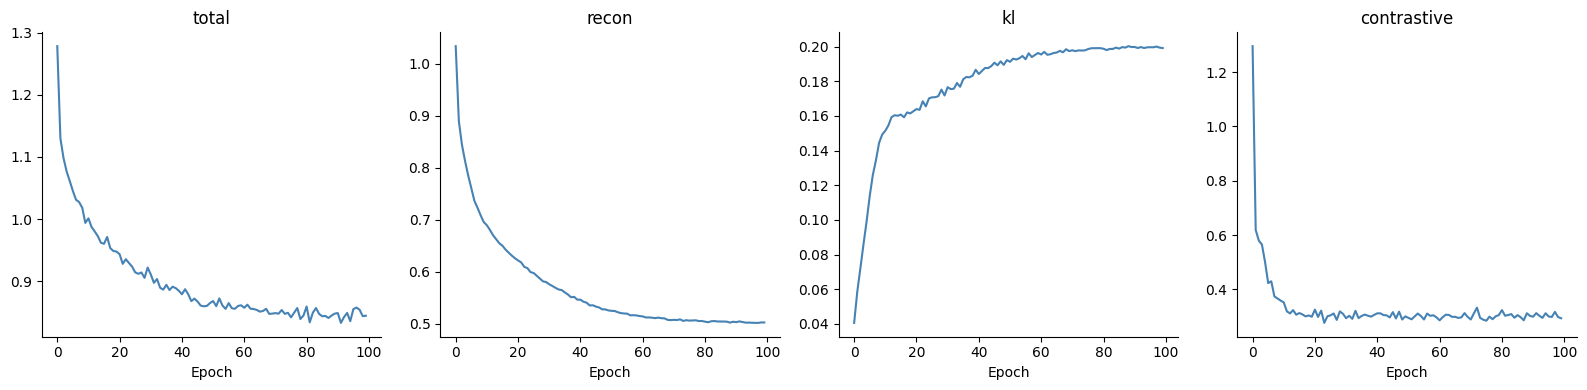

In [11]:
# Training curves
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (k, vals) in zip(axes, history.items()):
    ax.plot(vals, color='steelblue')
    ax.set_title(k)
    ax.set_xlabel('Epoch')
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/02_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Extract embeddings

In [12]:
@torch.no_grad()
def get_embeddings(model, expr_df, batch_size=512):
    """Extract mu (deterministic embedding) for all samples."""
    model.eval()
    tensor = torch.tensor(expr_df.values, dtype=torch.float32)
    loader = DataLoader(TensorDataset(tensor), batch_size=batch_size)
    mus = []
    for (x,) in loader:
        mu, _ = model.encode(x.to(device))
        mus.append(mu.cpu().numpy())
    return np.vstack(mus)


tcga_emb = get_embeddings(model, tcga)
ccle_emb = get_embeddings(model, ccle)

tcga_emb_df = pd.DataFrame(tcga_emb, index=tcga.index,
                            columns=[f'z{i}' for i in range(LATENT)])
ccle_emb_df = pd.DataFrame(ccle_emb, index=ccle.index,
                            columns=[f'z{i}' for i in range(LATENT)])

tcga_emb_df.to_parquet('data/tcga_embeddings.parquet')
ccle_emb_df.to_parquet('data/ccle_embeddings.parquet')

print('TCGA embeddings:', tcga_emb_df.shape)
print('CCLE embeddings:', ccle_emb_df.shape)

TCGA embeddings: (11060, 32)
CCLE embeddings: (486, 32)


## UMAP visualisation

In [19]:
# Xena encodes cancer types as floats — map back to TCGA abbreviations
tcga_code_map = {
    1.0: 'ACC', 2.0: 'BLCA', 3.0: 'BRCA', 4.0: 'CESC', 5.0: 'CHOL',
    6.0: 'COAD', 7.0: 'DLBC', 8.0: 'ESCA', 9.0: 'GBM', 10.0: 'HNSC',
    11.0: 'KICH', 12.0: 'KIRC', 13.0: 'KIRP', 14.0: 'LAML', 15.0: 'LGG',
    16.0: 'LIHC', 17.0: 'LUAD', 18.0: 'LUSC', 19.0: 'MESO', 20.0: 'OV',
    21.0: 'PAAD', 22.0: 'PCPG', 23.0: 'PRAD', 24.0: 'READ', 25.0: 'SARC',
    26.0: 'SKCM', 27.0: 'STAD', 28.0: 'TGCT', 29.0: 'THCA', 30.0: 'THYM',
    31.0: 'UCEC', 32.0: 'UCS', 33.0: 'UVM'
}

tcga_clin['cancer_type'] = tcga_clin['cancer_type'].map(tcga_code_map)
print(tcga_clin['cancer_type'].value_counts().head(10))

cancer_type
BLCA    1215
KICH     606
LIHC     576
TGCT     572
GBM      566
THYM     555
LUAD     552
PCPG     550
LAML     529
CHOL     492
Name: count, dtype: int64


In [20]:
# Fit UMAP on TCGA embeddings
print('Running UMAP...')
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    random_state=42, metric='cosine')
tcga_2d = reducer.fit_transform(tcga_emb)

# Also project CCLE into same space
ccle_2d = reducer.transform(ccle_emb)
print('UMAP done.')

Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done.


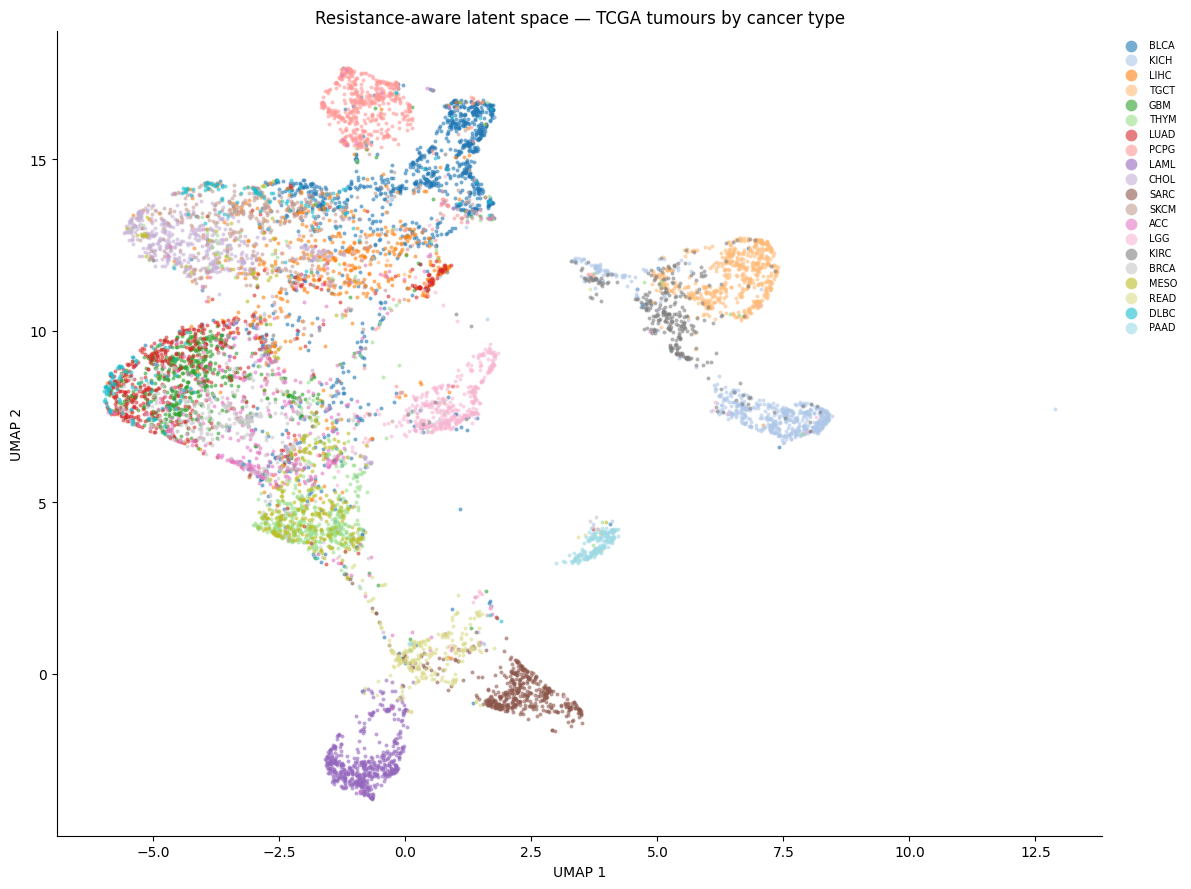

Saved figures/02_umap_cancer_type.png


In [21]:
# ── Figure 1: UMAP coloured by cancer type ──
# Align clinical labels to TCGA embedding order
ct = tcga_clin['cancer_type'].reindex(tcga.index).fillna('Unknown')
unique_ct = ct.value_counts().index[:20].tolist()
palette   = dict(zip(unique_ct, sns.color_palette('tab20', len(unique_ct))))

fig, ax = plt.subplots(figsize=(12, 9))
for ct_name in unique_ct:
    mask = ct == ct_name
    ax.scatter(tcga_2d[mask, 0], tcga_2d[mask, 1],
               c=[palette[ct_name]], label=ct_name, s=8, alpha=0.6, linewidths=0)

ax.legend(markerscale=3, fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left',
          frameon=False)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title('Resistance-aware latent space — TCGA tumours by cancer type')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/02_umap_cancer_type.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved figures/02_umap_cancer_type.png')

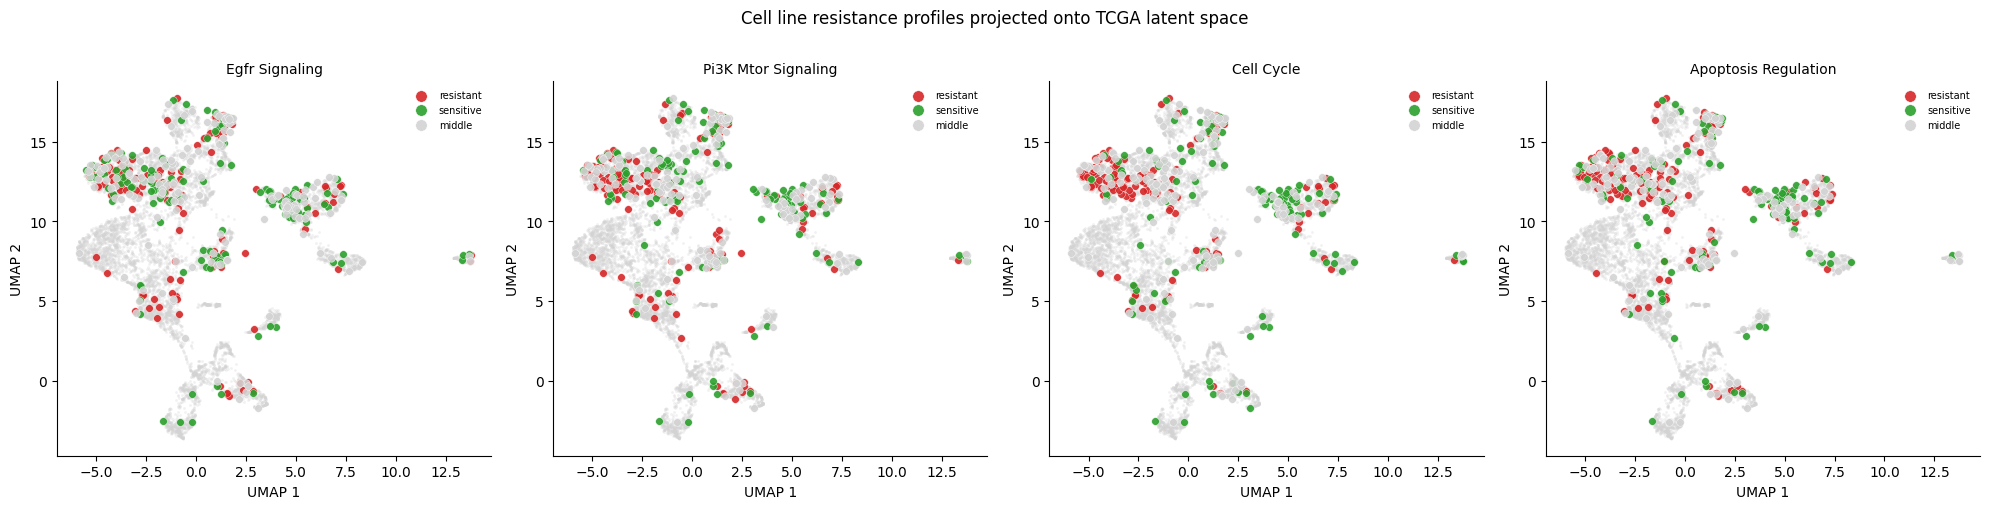

Saved figures/02_umap_resistance.png


In [15]:
# ── Figure 2: CCLE cell lines overlaid, coloured by resistance label ──
# Pick 4 biologically important pathways to show
SHOW_PATHWAYS = ['egfr_signaling', 'pi3k_mtor_signaling', 'cell_cycle', 'apoptosis_regulation']
SHOW_PATHWAYS = [p for p in SHOW_PATHWAYS if p in resist.columns][:4]

fig, axes = plt.subplots(1, len(SHOW_PATHWAYS), figsize=(5 * len(SHOW_PATHWAYS), 5))
if len(SHOW_PATHWAYS) == 1:
    axes = [axes]

colour_map = {'resistant': '#d62728', 'sensitive': '#2ca02c', 'middle': 'lightgray'}

for ax, pathway in zip(axes, SHOW_PATHWAYS):
    # TCGA in background (grey)
    ax.scatter(tcga_2d[:, 0], tcga_2d[:, 1],
               c='lightgray', s=4, alpha=0.3, linewidths=0)

    # CCLE cell lines coloured by resistance label for this pathway
    labels_here = resist[pathway].reindex(ccle.index)
    for lbl, colour in colour_map.items():
        mask = labels_here == lbl
        ax.scatter(ccle_2d[mask, 0], ccle_2d[mask, 1],
                   c=colour, label=lbl, s=30, alpha=0.9,
                   edgecolors='white', linewidths=0.3)

    ax.set_title(pathway.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    ax.legend(fontsize=7, markerscale=1.5, frameon=False)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Cell line resistance profiles projected onto TCGA latent space', y=1.01)
plt.tight_layout()
plt.savefig('figures/02_umap_resistance.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved figures/02_umap_resistance.png')

In [17]:
# Check what your cancer_type column actually looks like
print(tcga_clin['cancer_type'].value_counts().head(10))
print(tcga_clin['cancer_type'].dtype)

cancer_type
2.0     1215
11.0     606
16.0     576
28.0     572
9.0      566
30.0     555
17.0     552
22.0     550
14.0     529
5.0      492
Name: count, dtype: int64
float64


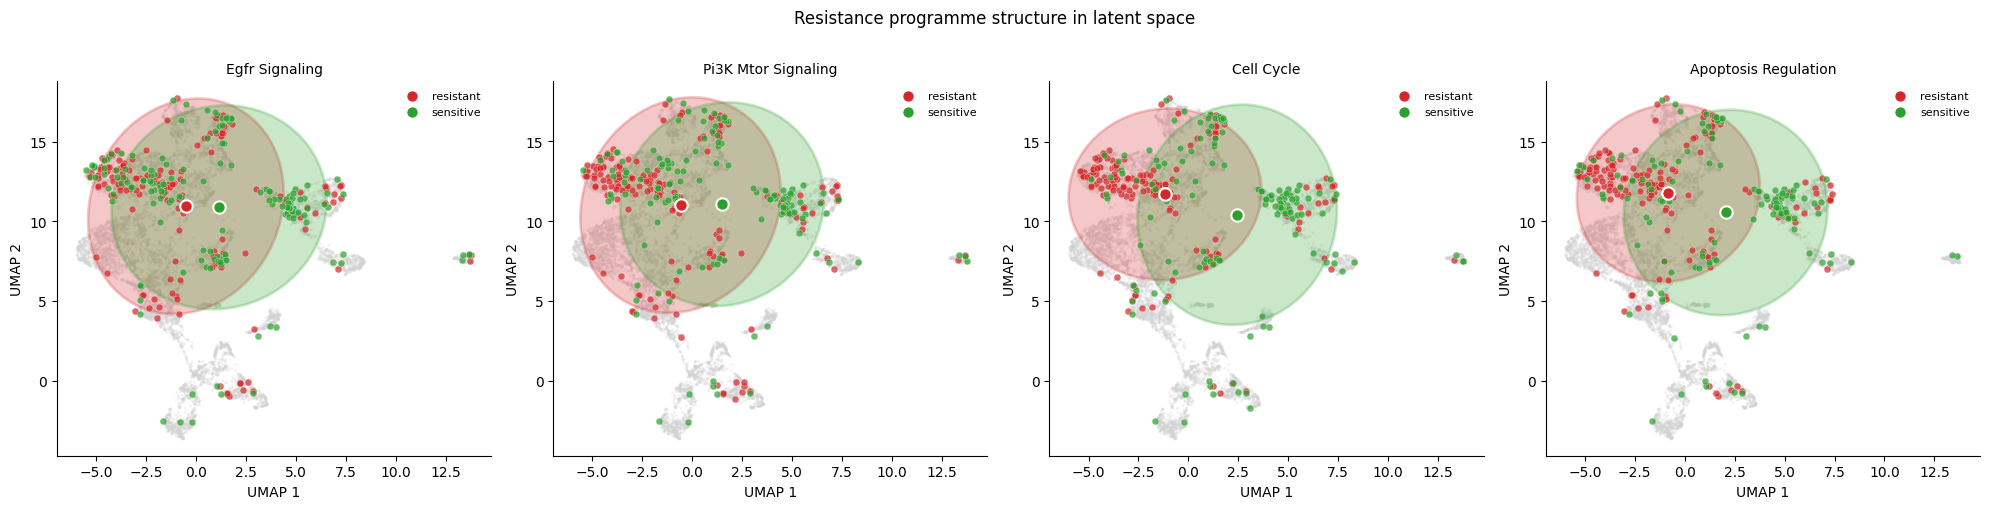

In [18]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

fig, axes = plt.subplots(1, len(SHOW_PATHWAYS), figsize=(5 * len(SHOW_PATHWAYS), 5))

def confidence_ellipse(x, y, ax, colour, label, n_std=1.5):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1] + 1e-8)
    rx, ry = np.sqrt(1 + pearson) * n_std, np.sqrt(1 - pearson) * n_std
    ellipse = Ellipse((0, 0), width=rx * 2 * np.sqrt(cov[0,0]),
                      height=ry * 2 * np.sqrt(cov[1,1]),
                      facecolor=colour, alpha=0.25, edgecolor=colour, linewidth=2)
    mean_x, mean_y = np.mean(x), np.mean(y)
    t = transforms.Affine2D().rotate_deg(45 * pearson).translate(mean_x, mean_y)
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)
    ax.scatter([mean_x], [mean_y], c=colour, s=80, zorder=5,
               edgecolors='white', linewidths=1.5, label=label)

colour_map = {'resistant': '#d62728', 'sensitive': '#2ca02c'}

for ax, pathway in zip(axes, SHOW_PATHWAYS):
    ax.scatter(tcga_2d[:, 0], tcga_2d[:, 1],
               c='lightgray', s=4, alpha=0.3, linewidths=0)

    labels_here = resist[pathway].reindex(ccle.index)
    for lbl, colour in colour_map.items():
        mask = (labels_here == lbl).values
        ax.scatter(ccle_2d[mask, 0], ccle_2d[mask, 1],
                   c=colour, s=25, alpha=0.7,
                   edgecolors='white', linewidths=0.3, zorder=4)
        confidence_ellipse(ccle_2d[mask, 0], ccle_2d[mask, 1],
                           ax, colour, lbl)

    ax.set_title(pathway.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Resistance programme structure in latent space', y=1.01)
plt.tight_layout()
plt.savefig('figures/02_umap_resistance_ellipses.png', dpi=200, bbox_inches='tight')
plt.show()

In [16]:
print('Notebook 02 complete.')
print('Files saved:')
print('  data/tcga_embeddings.parquet')
print('  data/ccle_embeddings.parquet')
print('  models/vae.pt')
print('  figures/02_umap_cancer_type.png')
print('  figures/02_umap_resistance.png')
print()
print('Next: 03_metastasis_prediction.ipynb')

Notebook 02 complete.
Files saved:
  data/tcga_embeddings.parquet
  data/ccle_embeddings.parquet
  models/vae.pt
  figures/02_umap_cancer_type.png
  figures/02_umap_resistance.png

Next: 03_metastasis_prediction.ipynb
